# mechanism_viewer examples

## Use a dendrogram to compare missingness patterns

This notebook contains examples of how to use `missingness_dendrogram()` from `viewer_dendrogram.py`. The function groups columns according to the similarity of the rows in which their values are missing.

> Note: The dendrogram is an exploratory visualization. Columns placed close together have similar missingness patterns, but this alone does not determine whether their mechanisms are MCAR, MAR, or MNAR.

### 1. Generate a synthetic dataset with missing values

The dataset contains one complete column and five incomplete columns. Different missing rates and mechanisms are included so that the clustering can be inspected.

In [1]:
from mechanism_viewer import generate_dataset_with_missingness, ColType

data = generate_dataset_with_missingness(250, [ColType.CONTINUOUS, ColType.CONTINUOUS, ColType.CONTINUOUS,
        										ColType.CONTINUOUS, ColType.CONTINUOUS, ColType.CONTINUOUS],
    									1, ["MAR", "MAR", "MCAR", "MCAR", "MNAR"], [0.20, 0.35, 0.20, 0.35, 0.25])

display(data.head())

,Col1,Col2,Col3,Col4,Col5,Col6
0,0.304717,-0.368249,NaN,0.011451,-0.059283,NaN
1,-1.039984,0.341556,0.895185,-0.299265,-0.729287,NaN
2,0.750451,NaN,NaN,-1.015068,-0.414473,-0.796911
3,0.940565,NaN,NaN,NaN,0.633910,0.301971
4,-1.951035,-0.245278,-2.964529,NaN,NaN,-0.725392


### 2. Plot the missingness dendrogram

The dendrogram converts each incomplete column into a binary missingness indicator, where 1 represents a missing value and 0 represents an observed value. It then groups columns whose missing values tend to occur in similar rows.

As a consequence, columns joined at a lower distance have more similar missingness patterns, than columns whose missing rows were selected independently.

> Note: The dendrogram groups columns according to missingness similarity, but it does not identify the missing-data mechanism by itself.

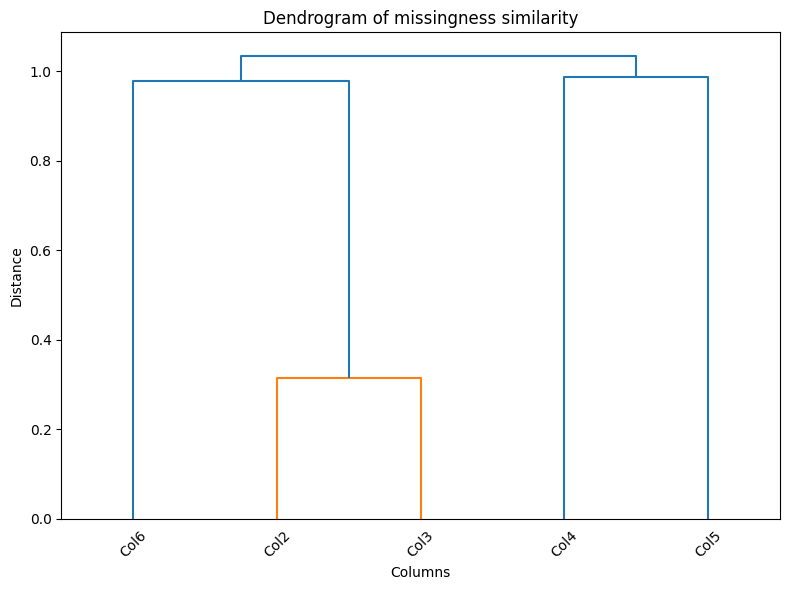

In [2]:
from mechanism_viewer import missingness_dendrogram

fig_dendrogram, ax_dendrogram = missingness_dendrogram(data, display_plot=True,)

In this synthetic example, columns generated from the same dependency are grouped more closely. That is the case of `Col2` and `Col3`, with a distance between `0.2` and `0.4`, since they both have MAR missing-data mechanism where the missing values depend on `Col1`. However, despite `Col4` and `Col5` being MCAR missing columns, their distance is high, because they do not share the same random seed for missingness generation. 

### 3. Linkage method

Hierarchical clustering builds the dendrogram by repeatedly merging the two most similar columns or groups of columns. The `linkage_method` parameter determines how the distance between two groups is calculated.

- **`"average"` (default):** Uses the average distance between all pairs of columns in the two groups. It generally produces balanced clusters and is a good general-purpose choice.
- **`"complete"`:** Uses the largest distance between the two groups. It tends to produce compact and clearly separated clusters.
- **`"single"`:** Uses the smallest distance between the two groups. It can create long chains of connected columns.
- **`"weighted"`:** Uses the average distance between groups while giving equal weight to each group, regardless of how many columns it contains.

Changing the linkage method may alter the structure of the dendrogram, although the underlying missingness data remain unchanged.

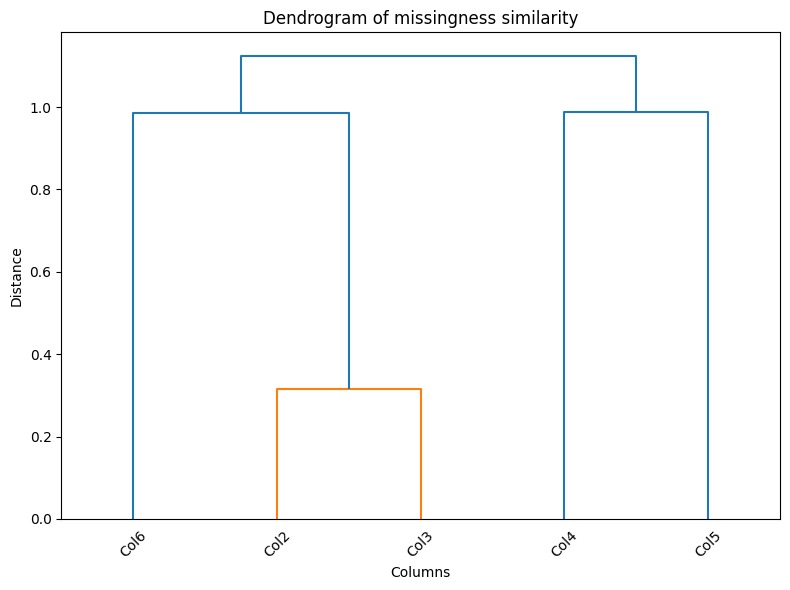

In [4]:
fig_complete, ax_complete = missingness_dendrogram(data, linkage_method="complete", display_plot=True)

### 4. Select columns

The function uses all eligible columns in the dataframe. To focus on specific columns, pass a dataframe containing only those columns.

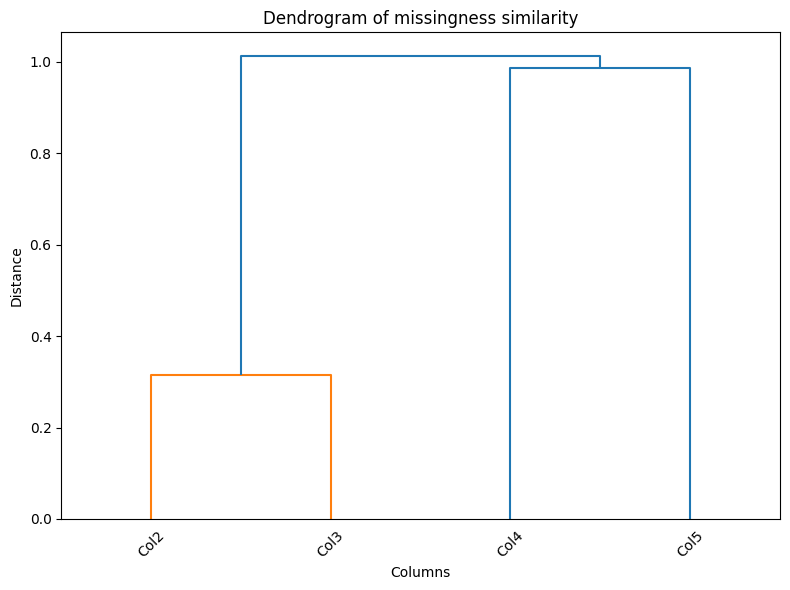

In [5]:
subset = data[["Col2", "Col3", "Col4", "Col5"]]

fig_subset, ax_subset = missingness_dendrogram(subset, display_plot=True)

> Note: Complete columns and columns containing only missing values are automatically excluded because their missingness indicators have no variation, making their missingness correlation undefined or uninformative.